# import Libraries

In [3]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

# read dataset

In [4]:
df = pd.read_csv('solar_weather.csv')
df.head()

,Time,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
0,2017-01-01 00:00:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
1,2017-01-01 00:15:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
2,2017-01-01 00:30:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
3,2017-01-01 00:45:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
4,2017-01-01 01:00:00,0,0.0,1.7,1020,100,5.2,0.0,0.0,100,0,0,450,0.0,4,1,1


In [5]:
df.shape

(196776, 17)

# check nulls

In [6]:
df.isna().sum()

Time                      0
Energy delta[Wh]          0
GHI                       0
temp                      0
pressure                  0
humidity                  0
wind_speed                0
rain_1h                   0
snow_1h                   0
clouds_all                0
isSun                     0
sunlightTime              0
dayLength                 0
SunlightTime/daylength    0
weather_type              0
hour                      0
month                     0
dtype: int64

# chacks duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196776 entries, 0 to 196775
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Time                    196776 non-null  object 
 1   Energy delta[Wh]        196776 non-null  int64  
 2   GHI                     196776 non-null  float64
 3   temp                    196776 non-null  float64
 4   pressure                196776 non-null  int64  
 5   humidity                196776 non-null  int64  
 6   wind_speed              196776 non-null  float64
 7   rain_1h                 196776 non-null  float64
 8   snow_1h                 196776 non-null  float64
 9   clouds_all              196776 non-null  int64  
 10  isSun                   196776 non-null  int64  
 11  sunlightTime            196776 non-null  int64  
 12  dayLength               196776 non-null  int64  
 13  SunlightTime/daylength  196776 non-null  float64
 14  weather_type        

In [9]:
df.columns

Index(['Time', 'Energy delta[Wh]', 'GHI', 'temp', 'pressure', 'humidity',
       'wind_speed', 'rain_1h', 'snow_1h', 'clouds_all', 'isSun',
       'sunlightTime', 'dayLength', 'SunlightTime/daylength', 'weather_type',
       'hour', 'month'],
      dtype='object')

In [10]:
df.head()

,Time,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
0,2017-01-01 00:00:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
1,2017-01-01 00:15:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
2,2017-01-01 00:30:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
3,2017-01-01 00:45:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
4,2017-01-01 01:00:00,0,0.0,1.7,1020,100,5.2,0.0,0.0,100,0,0,450,0.0,4,1,1


# drop non importent feature 

In [11]:
df.drop("Time", axis=1, inplace=True)
df.drop("month", axis=1, inplace=True)
df.head()

,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour
0,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0
1,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0
2,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0
3,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0
4,0,0.0,1.7,1020,100,5.2,0.0,0.0,100,0,0,450,0.0,4,1


In [12]:
df = df.rename(columns={"Energy delta[Wh]":"Energy"})
df = df.rename(columns={"rain_1h":"Rain"})
df = df.rename(columns={"snow_1h":"Snow"})
df = df.rename(columns={"SunlightTime/daylength":"Sunlight_Ratio"})


In [13]:
df.head()

,Energy,GHI,temp,pressure,humidity,wind_speed,Rain,Snow,clouds_all,isSun,sunlightTime,dayLength,Sunlight_Ratio,weather_type,hour
0,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0
1,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0
2,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0
3,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0
4,0,0.0,1.7,1020,100,5.2,0.0,0.0,100,0,0,450,0.0,4,1


# check description

In [14]:
df.describe()

,Energy,GHI,temp,pressure,humidity,wind_speed,Rain,Snow,clouds_all,isSun,sunlightTime,dayLength,Sunlight_Ratio,weather_type,hour
count,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000,196776.000000
mean,573.008228,32.596538,9.790521,1015.292780,79.810566,3.937746,0.066035,0.007148,65.974387,0.519962,211.721094,748.644347,0.265187,3.198398,11.498902
std,1044.824047,52.172018,7.995428,9.585773,15.604459,1.821694,0.278913,0.069710,36.628593,0.499603,273.902186,194.870208,0.329023,1.289939,6.921887
min,0.000000,0.000000,-16.600000,977.000000,22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,450.000000,0.000000,1.000000,0.000000
25%,0.000000,0.000000,3.600000,1010.000000,70.000000,2.600000,0.000000,0.000000,34.000000,0.000000,0.000000,570.000000,0.000000,2.000000,5.000000
50%,0.000000,1.600000,9.300000,1016.000000,84.000000,3.700000,0.000000,0.000000,82.000000,1.000000,30.000000,765.000000,0.050000,4.000000,11.000000
75%,577.000000,46.800000,15.700000,1021.000000,92.000000,5.000000,0.000000,0.000000,100.000000,1.000000,390.000000,930.000000,0.530000,4.000000,17.000000
max,5020.000000,229.200000,35.800000,1047.000000,100.000000,14.300000,8.090000,2.820000,100.000000,1.000000,1020.000000,1020.000000,1.000000,5.000000,23.000000


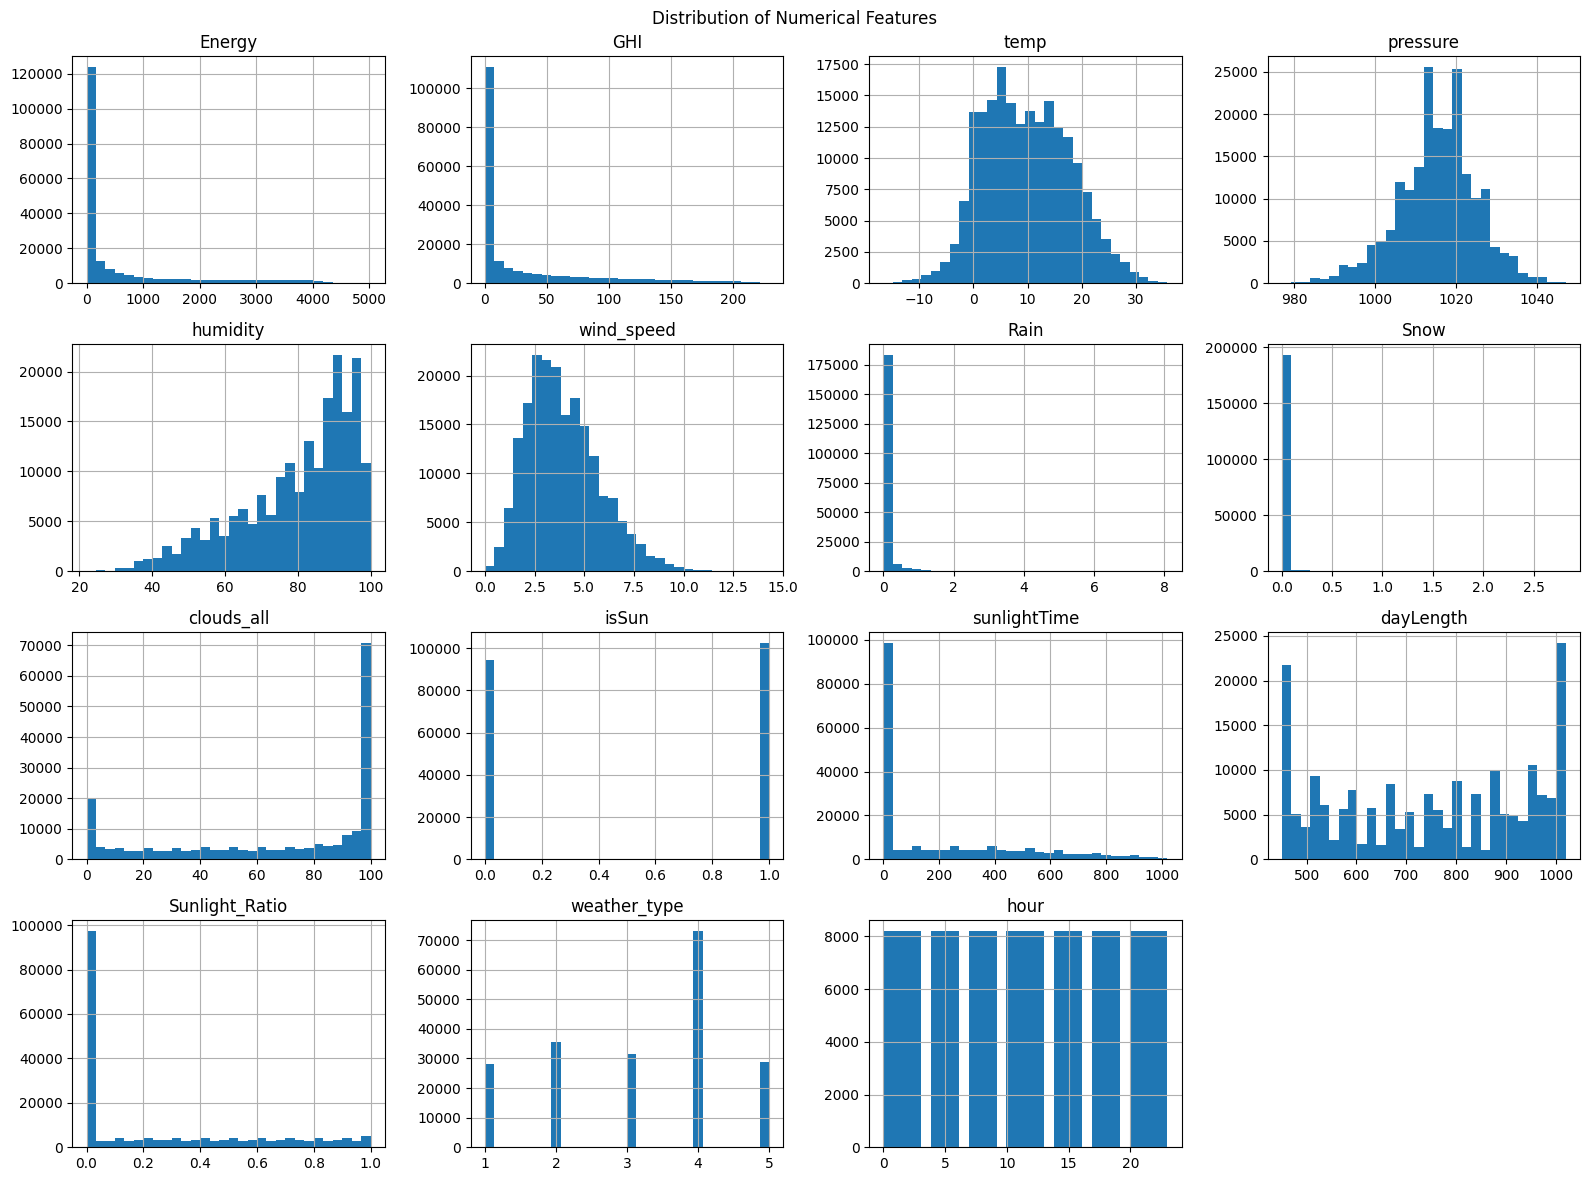

In [15]:
df.hist(figsize=(16, 12), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

# chick for outlier 

In [16]:

Q1 = df["temp"].quantile(0.25)
Q3 = df["temp"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

temp_outliers = df[(df["temp"] < lower) | (df["temp"] > upper)]

print("Lower Bound:", lower)
print("Upper Bound:", upper)
print("Number of Outliers:", len(temp_outliers))

print(temp_outliers[["temp"]].head())

Lower Bound: -14.549999999999999
Upper Bound: 33.849999999999994
Number of Outliers: 140
       temp
40140 -14.7
40141 -14.7
40142 -14.7
40143 -14.7
40144 -15.0


In [17]:
print("Original Shape:", df.shape)

df = df[(df["temp"] >= lower) & (df["temp"] <= upper)]
print("After Removing Temperature Outliers:", df.shape)

Original Shape: (196776, 15)
After Removing Temperature Outliers: (196636, 15)


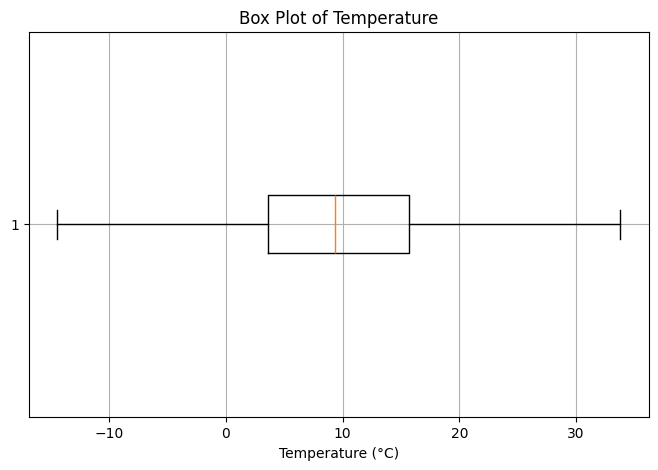

In [18]:
plt.figure(figsize=(8,5))
plt.boxplot(df["temp"], vert=False)
plt.title("Box Plot of Temperature")
plt.xlabel("Temperature (°C)")
plt.grid(True)
plt.show()

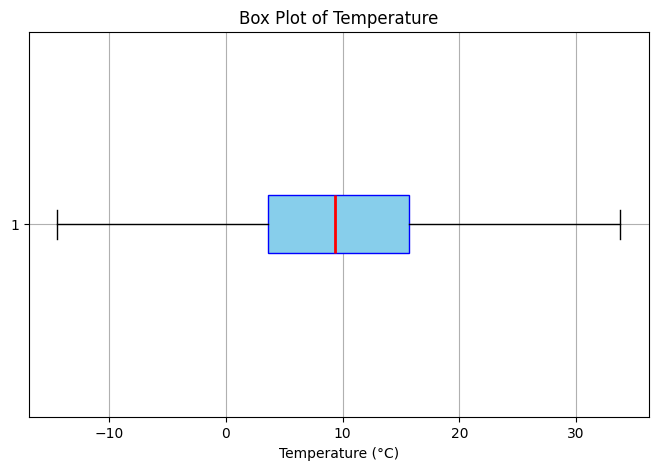

In [19]:
plt.figure(figsize=(8,5))

plt.boxplot(
    df["temp"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="skyblue", color="blue"),
    medianprops=dict(color="red", linewidth=2),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=dict(marker='o', markerfacecolor='orange', markeredgecolor='black', markersize=5)
)

plt.title("Box Plot of Temperature")
plt.xlabel("Temperature (°C)")
plt.grid(True)
plt.show()

# co realation

In [20]:
df.corr()

,Energy,GHI,temp,pressure,humidity,wind_speed,Rain,Snow,clouds_all,isSun,sunlightTime,dayLength,Sunlight_Ratio,weather_type,hour
Energy,1.000000,0.914628,0.378339,0.115503,-0.544430,0.029141,-0.059820,-0.050900,-0.190093,0.526840,0.437101,0.280359,0.402322,-0.169882,-0.081115
GHI,0.914628,1.000000,0.492070,0.096853,-0.601607,0.016911,-0.048460,-0.051792,-0.188432,0.600243,0.539713,0.400666,0.471496,-0.163239,-0.084167
temp,0.378339,0.492070,1.000000,-0.065836,-0.515496,-0.081254,0.074216,-0.123617,-0.116966,0.345266,0.503486,0.707108,0.381602,-0.088277,0.103215
pressure,0.115503,0.096853,-0.065836,1.000000,-0.121426,-0.313989,-0.201891,-0.135524,-0.264105,0.015015,0.007185,0.053499,0.002179,-0.320220,-0.002188
humidity,-0.544430,-0.601607,-0.515496,-0.121426,1.000000,-0.112799,0.126619,0.095721,0.284993,-0.388763,-0.597351,-0.415912,-0.527249,0.286488,-0.194736
wind_speed,0.029141,0.016911,-0.081254,-0.313989,-0.112799,1.000000,0.123516,0.072756,0.146464,0.082565,0.054404,-0.210398,0.092530,0.194081,-0.003698
Rain,-0.059820,-0.048460,0.074216,-0.201891,0.126619,0.123516,1.000000,-0.024294,0.173337,0.045335,0.059523,0.048520,0.050304,0.330737,0.011383
Snow,-0.050900,-0.051792,-0.123617,-0.135524,0.095721,0.072756,-0.024294,1.000000,0.088437,-0.023232,-0.038260,-0.109057,-0.021421,0.143232,-0.004614
clouds_all,-0.190093,-0.188432,-0.116966,-0.264105,0.284993,0.146464,0.173337,0.088437,1.000000,-0.002603,-0.029879,-0.234751,0.005181,0.910856,-0.019366
isSun,0.526840,0.600243,0.345266,0.015015,-0.388763,0.082565,0.045335,-0.023232,-0.002603,1.000000,0.742714,0.270555,0.774391,0.024683,-0.150887


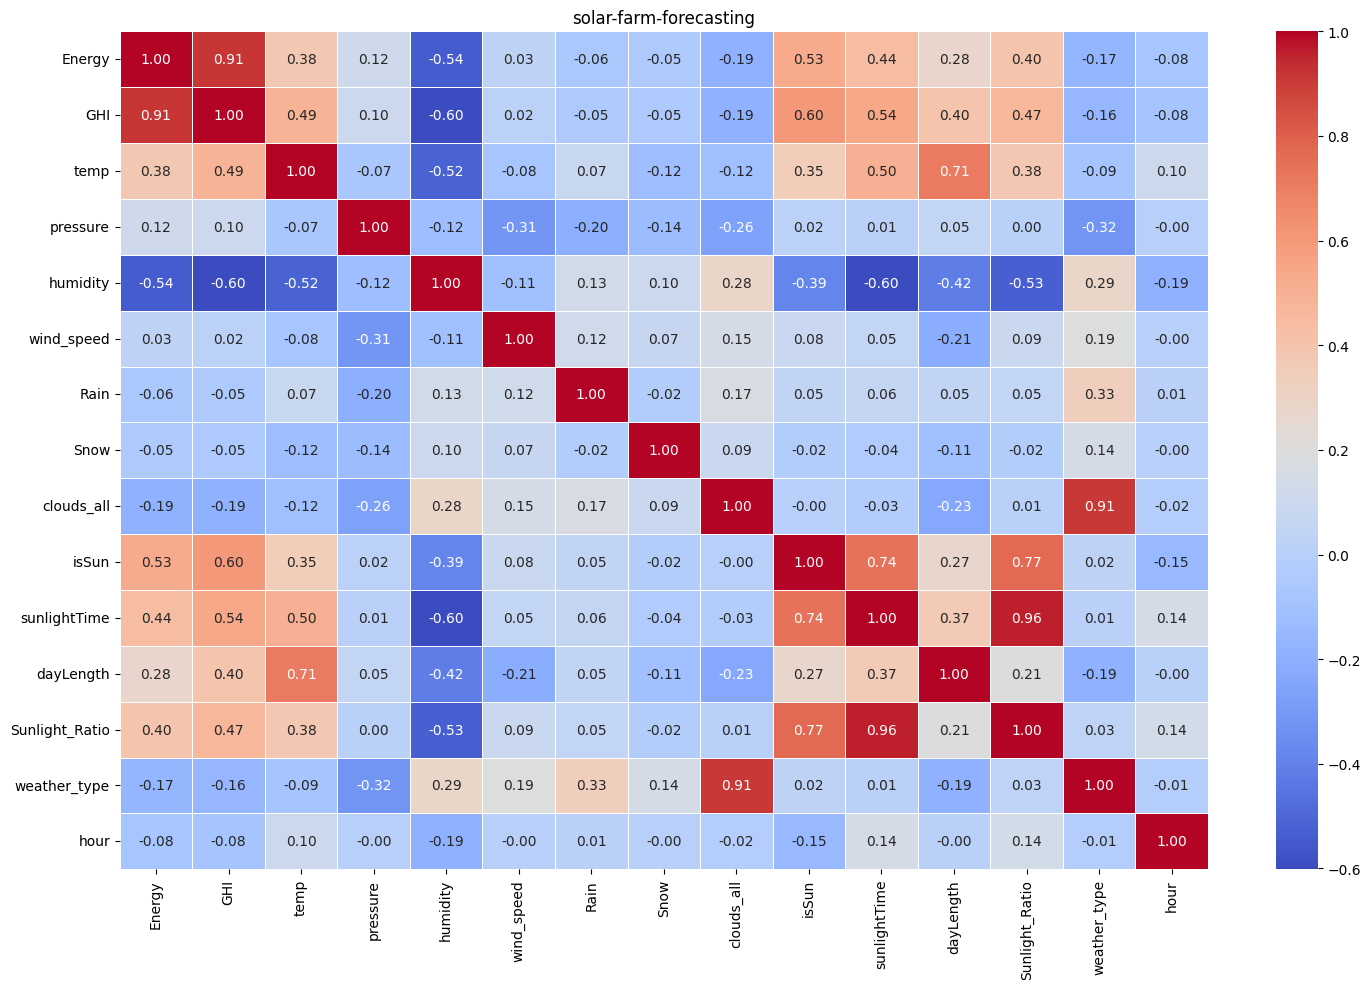

In [21]:
# 1. Set the figure size BEFORE creating the plot
plt.figure(figsize=(15, 10))

# 2. Use your correlation matrix (replace df.corr() if needed)
# annot=True shows the values, fmt=".2f" keeps them at 2 decimal places
# cmap='coolwarm' is a standard color palette for correlations
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 3. Add titles and labels
plt.title('solar-farm-forecasting')

# 4. Display the plot
plt.tight_layout() # Ensures the labels aren't cut off
plt.show()


# Correlation of Energy with all features

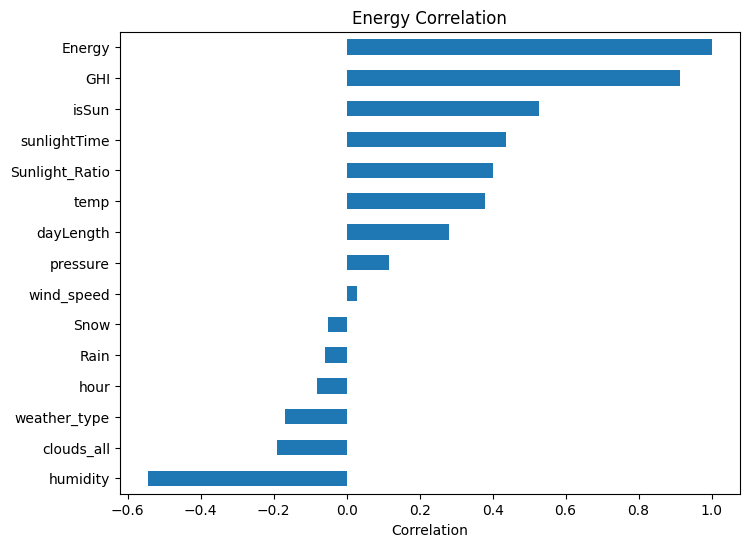

In [22]:

# Correlation of Energy with all features
corr2 = df.corr(numeric_only=True)["Energy"].sort_values()

corr2.plot(kind="barh", figsize=(8,6))
plt.title("Energy Correlation")
plt.xlabel("Correlation")
plt.show()

In [23]:
df.head()

,Energy,GHI,temp,pressure,humidity,wind_speed,Rain,Snow,clouds_all,isSun,sunlightTime,dayLength,Sunlight_Ratio,weather_type,hour
0,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0
1,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0
2,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0
3,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0
4,0,0.0,1.7,1020,100,5.2,0.0,0.0,100,0,0,450,0.0,4,1


# dependent  and independent variable 

In [24]:
x = df.drop("Energy", axis=1)
y = df["Energy"]

In [25]:
x.head()

,GHI,temp,pressure,humidity,wind_speed,Rain,Snow,clouds_all,isSun,sunlightTime,dayLength,Sunlight_Ratio,weather_type,hour
0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0
1,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0
2,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0
3,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0
4,0.0,1.7,1020,100,5.2,0.0,0.0,100,0,0,450,0.0,4,1


In [26]:
x.shape

(196636, 14)

In [27]:
y.shape

(196636,)

# split 80/20

In [28]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.2,random_state=42)

# use scaler

In [29]:
scaler = StandardScaler()

xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

# LinearRegression

In [30]:
# Create and train the model
lr = LinearRegression()
lr.fit(xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
# Predict
ypred = lr.predict(xtest)

#  Evaluation metrics

In [32]:
# Evaluation metrics
mae = mean_absolute_error(ytest, ypred)
mse = mean_squared_error(ytest, ypred)
rmse = np.sqrt(mse)
r2 = r2_score(ytest, ypred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 222.18
MSE  : 155077.38
RMSE : 393.80
R²   : 0.8569


# Sava SCALER + LOGISTIC REGRESSION pkl file

In [33]:
joblib.dump(scaler, "scaler.pkl")
print("Scaler Saved Successfully!")

Scaler Saved Successfully!


In [34]:
joblib.dump(lr, "solar_energy_model_lr.pkl")
print("Model Saved Successfully!")

Model Saved Successfully!


# Random Forest Regressor

In [35]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
param_dist = {
    "n_estimators": [50, 100, 150],    
    "max_depth": [10, 12],           
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 5],
    "max_features": ["sqrt"]          
}

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,          
    min_samples_split=10,  
    min_samples_leaf=5,  
    max_features="sqrt",  
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=2,
    verbose=2
)


In [36]:
random_search.fit(xtrain, ytrain)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 12], 'max_features': ['sqrt'], 'min_samples_leaf': [2, 5], 'min_samples_split': [5, 10], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 

In [37]:
random_search.best_params_

{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 12}

In [38]:
random_search.best_score_

np.float64(0.9216622743752252)

In [39]:
random_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

# Train the model

In [40]:
# Train the model
rf.fit(xtrain, ytrain)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamp

In [41]:
ypred_rf = rf.predict(xtest)

In [42]:
mae = mean_absolute_error(ytest, ypred_rf)
mse = mean_squared_error(ytest, ypred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(ytest, ypred_rf)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 113.94
MSE  : 74309.02
RMSE : 272.60
R²   : 0.9314


In [43]:
joblib.dump(
    rf,
    "solar_energy_model_rf.joblib",
    compress=3
)
print("Model Saved Successfully!")

Model Saved Successfully!


# XGBoost

In [44]:
param_dist_xgb = {
    "n_estimators": [50, 100],          
    "max_depth": [3, 5, 6],             
    "learning_rate": [0.05, 0.1, 0.2],  
    "subsample": [0.7, 0.9],            
    "colsample_bytree": [0.7, 0.9]      
}

In [45]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    tree_method="hist",   
    n_jobs=2,             
    random_state=42
)

In [46]:


# 3. Setup the search configuration (Runs 30 total fits)
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=10,        
    cv=3,             
    scoring="r2",
    random_state=42,
    n_jobs=2,        
    verbose=2
)

In [47]:
random_search_xgb.fit(xtrain, ytrain)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.9], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... version

In [48]:
best_xgb = random_search_xgb.best_estimator_

In [49]:
# Train the model
xgb.fit(xtrain, ytrain)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [50]:
# Predict
ypred_xgb = xgb.predict(xtest)

In [51]:
# Evaluation metrics
mae = mean_absolute_error(ytest, ypred_xgb)
mse = mean_squared_error(ytest, ypred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(ytest, ypred_xgb)

print(f"XGBoost MAE  : {mae:.2f}")
print(f"XGBoost MSE  : {mse:.2f}")
print(f"XGBoost RMSE : {rmse:.2f}")
print(f"XGBoost R²   : {r2:.4f}")

XGBoost MAE  : 112.45
XGBoost MSE  : 69676.35
XGBoost RMSE : 263.96
XGBoost R²   : 0.9357


In [52]:
import joblib

joblib.dump(
    xgb,
    "solar_energy_model_xgb.joblib",
    compress=3
)
print("Model Saved Successfully!")

Model Saved Successfully!


## -------- Comparison  --------

In [53]:
# -------- Linear Regression --------
lr_mae = mean_absolute_error(ytest, ypred)
lr_mse = mean_squared_error(ytest, ypred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(ytest, ypred)

# -------- Random Forest Regressor --------
rf_mae = mean_absolute_error(ytest, ypred_rf)
rf_mse = mean_squared_error(ytest, ypred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(ytest, ypred_rf)

# -------- Tuned XGBoost Regressor --------
# (Assuming your tuned XGBoost predictions were saved as ypred_xgb)
xgb_mae = mean_absolute_error(ytest, ypred_xgb)
xgb_mse = mean_squared_error(ytest, ypred_xgb)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(ytest, ypred_xgb)

In [54]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [lr_mae, rf_mae, xgb_mae],
    "MSE": [lr_mse, rf_mse, xgb_mse],
    "RMSE": [lr_rmse, rf_rmse, xgb_rmse],
    "R² Score": [lr_r2, rf_r2, xgb_r2]
})

comparison = comparison.round(4)
print(comparison)

               Model       MAE          MSE      RMSE  R² Score
0  Linear Regression  222.1819  155077.3796  393.7987    0.8569
1      Random Forest  113.9395   74309.0206  272.5968    0.9314
2            XGBoost  112.4453   69676.3516  263.9628    0.9357


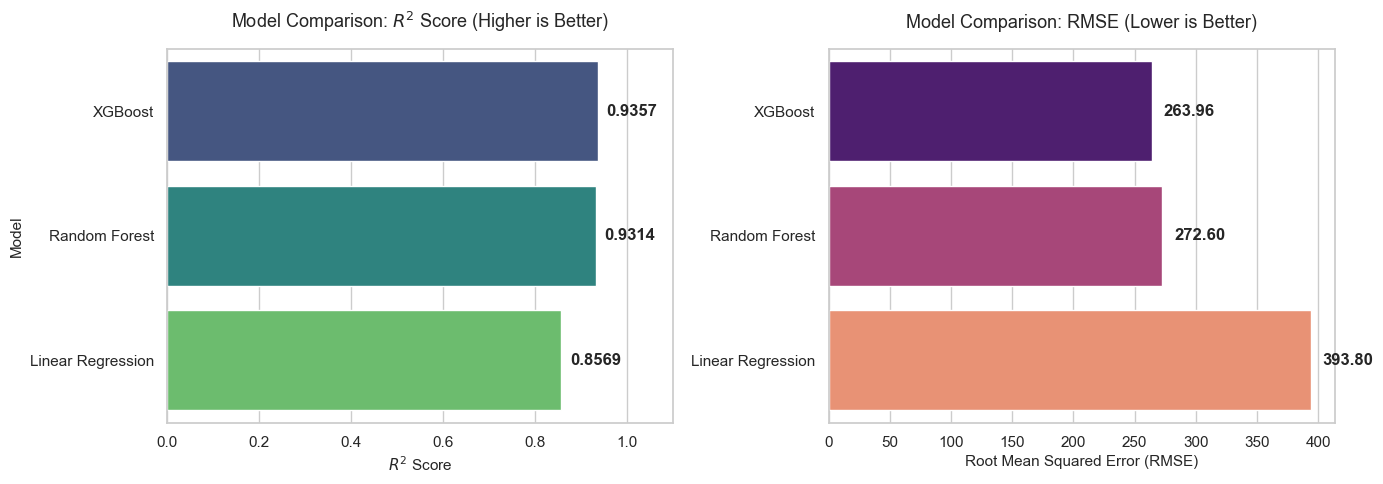

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting canvas theme
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. R² Score Plot (Sorted descending - higher performance at the top)
df_r2 = comparison.sort_values(by="R² Score", ascending=False)
sns.barplot(x="R² Score", y="Model", data=df_r2, ax=axes[0], palette="viridis", hue="Model")
axes[0].set_title("Model Comparison: $R^2$ Score (Higher is Better)", fontsize=13, pad=15)
axes[0].set_xlim(0, 1.1)  # Extra room for text labels
axes[0].set_xlabel("$R^2$ Score", fontsize=11)
axes[0].set_ylabel("Model", fontsize=11)

# Append data value tags to the right side of each bar
for index, value in enumerate(df_r2["R² Score"]):
    axes[0].text(value + 0.02, index, f"{value:.4f}", va='center', fontweight='bold')

# 2. RMSE Plot (Sorted ascending - lowest error at the top)
df_rmse = comparison.sort_values(by="RMSE", ascending=True)
sns.barplot(x="RMSE", y="Model", data=df_rmse, ax=axes[1], palette="magma", hue="Model")
axes[1].set_title("Model Comparison: RMSE (Lower is Better)", fontsize=13, pad=15)
axes[1].set_xlabel("Root Mean Squared Error (RMSE)", fontsize=11)
axes[1].set_ylabel("", fontsize=11)  # Clear redundant axis label

# Append data value tags to the right side of each bar
for index, value in enumerate(df_rmse["RMSE"]):
    axes[1].text(value + 10, index, f"{value:.2f}", va='center', fontweight='bold')

# Automatically clean up margins and display the figures
plt.tight_layout()
plt.show()

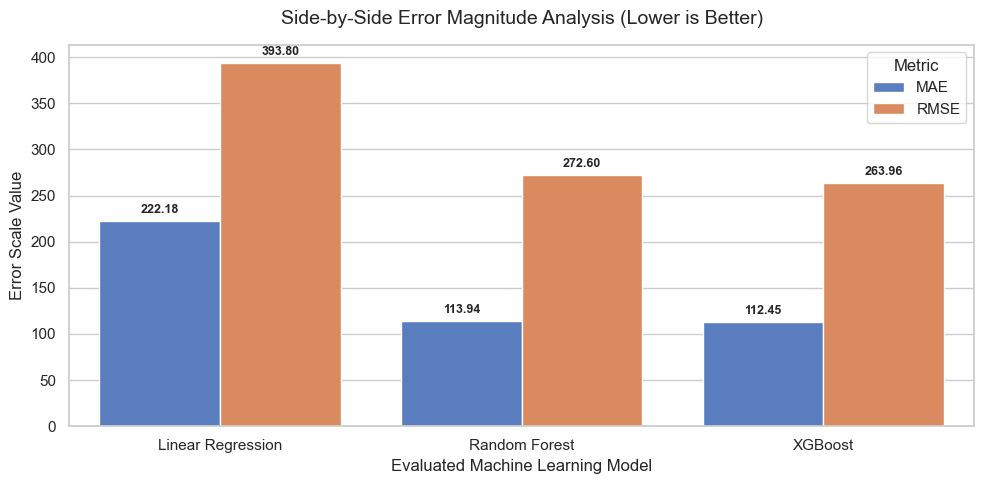

In [56]:
# Melt the dataframe to wide/long format for a grouped seaborn plot
error_metrics = comparison[comparison["Model"].isin(["Linear Regression", "Random Forest", "XGBoost"])]
melted_df = pd.melt(error_metrics, id_vars="Model", value_vars=["MAE", "RMSE"], 
                    var_name="Metric", value_name="Value")

plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="Value", hue="Metric", data=melted_df, palette="muted")

plt.title("Side-by-Side Error Magnitude Analysis (Lower is Better)", fontsize=14, pad=15)
plt.ylabel("Error Scale Value", fontsize=12)
plt.xlabel("Evaluated Machine Learning Model", fontsize=12)

# Annotate values on top of the bars
ax = plt.gca()
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', 
                    fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

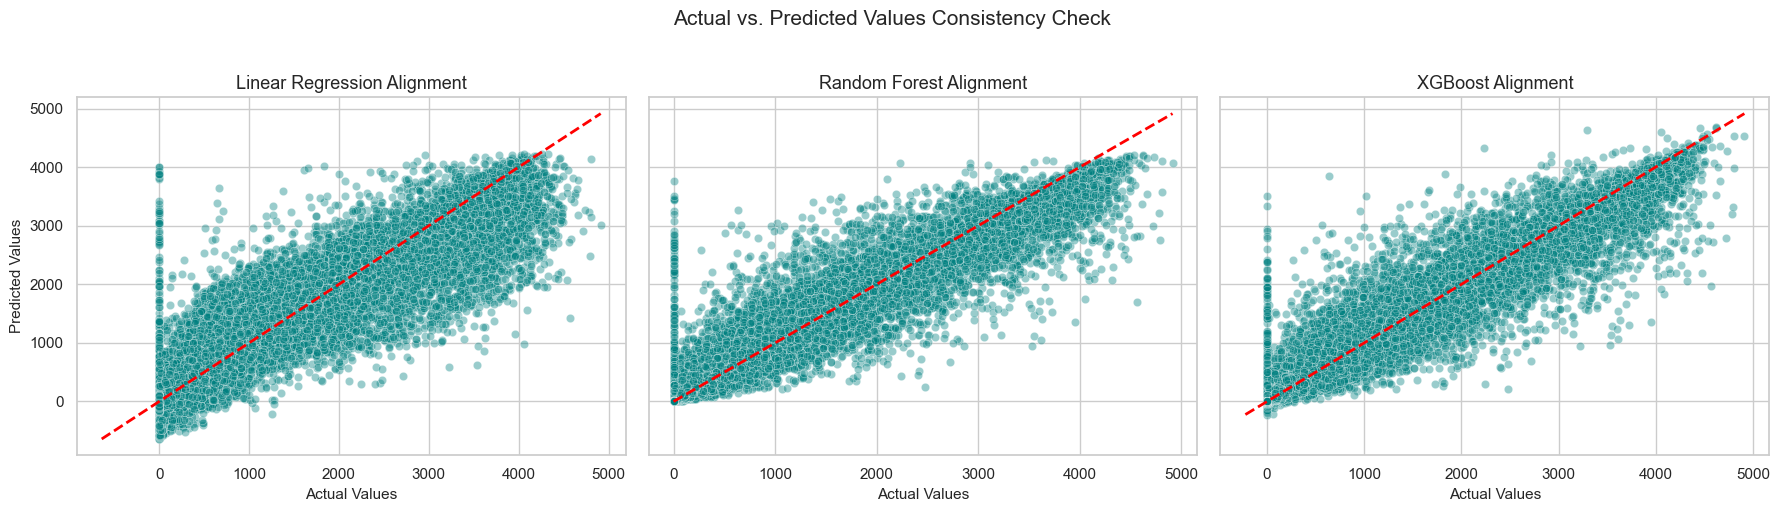

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

models_preds = [
    ("Linear Regression", ypred),
    ("Random Forest", ypred_rf),
    ("XGBoost", ypred_xgb)
]

for idx, (name, pred) in enumerate(models_preds):
    # Scatter plot of actual vs predicted
    sns.scatterplot(x=ytest, y=pred, ax=axes[idx], alpha=0.4, color='teal')
    
    # Perfect alignment reference line
    min_val = min(ytest.min(), pred.min())
    max_val = max(ytest.max(), pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
    
    axes[idx].set_title(f"{name} Alignment", fontsize=13)
    axes[idx].set_xlabel("Actual Values", fontsize=11)
    if idx == 0:
        axes[idx].set_ylabel("Predicted Values", fontsize=11)

plt.suptitle("Actual vs. Predicted Values Consistency Check", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Interpretation
     ower MAE → Better
     Lower MSE → Better
     Lower RMSE → Better
     Higher R² Score (closer to 1) → Better

# Proposed model XGBoost

In [58]:
# Double-check that you used 'ypred_xgb' here, NOT 'ypred'
xgb_mae = mean_absolute_error(ytest, ypred_xgb)
xgb_mse = mean_squared_error(ytest, ypred_xgb)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(ytest, ypred_xgb)

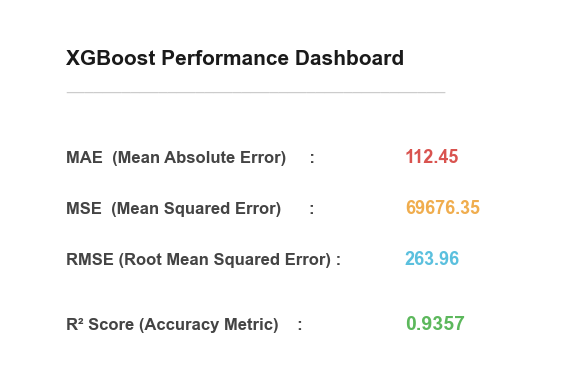

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set up the display panel
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis('off')  # Hide the default grid lines/axes

# 2. Add a styled background card container
ax.patch.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#ffffff')

# 3. Print the metric dashboard text lines dynamically
plt.text(0.1, 0.85, "XGBoost Performance Dashboard", fontsize=15, fontweight='bold', color='#1a1a1a')
plt.text(0.1, 0.78, "_________________________________________", fontsize=12, color='#cccccc')

# Metric line prints
plt.text(0.1, 0.58, f"MAE  (Mean Absolute Error)     :", fontsize=12, fontweight='semibold', color='#444444')
plt.text(0.7, 0.58, f"{xgb_mae:.2f}", fontsize=13, fontweight='bold', color='#d9534f')

plt.text(0.1, 0.44, f"MSE  (Mean Squared Error)      :", fontsize=12, fontweight='semibold', color='#444444')
plt.text(0.7, 0.44, f"{xgb_mse:.2f}", fontsize=13, fontweight='bold', color='#f0ad4e')

plt.text(0.1, 0.30, f"RMSE (Root Mean Squared Error) :", fontsize=12, fontweight='semibold', color='#444444')
plt.text(0.7, 0.30, f"{xgb_rmse:.2f}", fontsize=13, fontweight='bold', color='#5bc0de')

plt.text(0.1, 0.12, f"R² Score (Accuracy Metric)    :", fontsize=12, fontweight='semibold', color='#444444')
plt.text(0.7, 0.12, f"{xgb_r2:.4f}", fontsize=14, fontweight='bold', color='#5cb85c')

plt.tight_layout()
plt.show()

In [60]:
print(x.columns)

Index(['GHI', 'temp', 'pressure', 'humidity', 'wind_speed', 'Rain', 'Snow',
       'clouds_all', 'isSun', 'sunlightTime', 'dayLength', 'Sunlight_Ratio',
       'weather_type', 'hour'],
      dtype='object')


In [61]:
import pandas as pd
import numpy as np

# 1. Convert features array/dataframe cleanly back to structural pandas format
if isinstance(xtest, pd.DataFrame):
    clean_data = xtest.copy()
else:
    # If xtest is a numpy array, reconstruct columns using features list
    # fallback to generic numbering if names are unavailable
    feature_cols = x.columns if 'x' in locals() and hasattr(x, 'columns') else None
    clean_data = pd.DataFrame(xtest, columns=feature_cols)

# 2. Extract underlying arrays safely and flatten them to 1D vectors using .ravel()
actual_values = ytest.to_numpy().ravel() if hasattr(ytest, 'to_numpy') else np.array(ytest).ravel()
predicted_values = np.array(ypred_xgb).ravel()

# 3. Securely map target and model tracking prediction arrays as columns
clean_data["Actual_Value"] = actual_values
clean_data["XGB_Predicted"] = predicted_values

# 4. Generate prediction error analysis metrics
clean_data["Residual_Error"] = clean_data["Actual_Value"] - clean_data["XGB_Predicted"]

# 5. Format layout precision to 4 decimal places
clean_data = clean_data.round(4)

# 6. Save the structured CSV dataset directly to the working workspace directory
output_filename = "solar_energy_predictions.csv"
clean_data.to_csv(output_filename, index=False)

print(f"🎉 Clean dataset successfully built and saved as '{output_filename}'!")
print(f"Final Data Shape: {clean_data.shape}")
print("\nFirst 5 Rows Pipeline Preview:")
print(clean_data.head())

🎉 Clean dataset successfully built and saved as 'solar_energy_predictions.csv'!
Final Data Shape: (39328, 17)

First 5 Rows Pipeline Preview:
      GHI    temp  pressure  humidity  wind_speed    Rain    Snow  clouds_all  \
0 -0.6258 -0.5015    0.2829    0.9107      0.5301 -0.2371 -0.1025      0.7921   
1 -0.6258 -1.2168   -1.6997    0.8464      0.9147 -0.2371  3.6336      0.1912   
2 -0.5606 -0.9282   -0.8649    0.2038      2.3432  0.5507 -0.1025      0.9286   
3 -0.6258 -1.0787   -2.2214    0.9107      0.3652 -0.2371 -0.1025      0.9286   
4 -0.6258 -0.9156    0.3873    0.5251      0.0356 -0.2371 -0.1025      0.9286   

    isSun  sunlightTime  dayLength  Sunlight_Ratio  weather_type    hour  \
0 -1.0426       -0.7737    -1.0743         -0.8066        0.6208  0.9411   
1 -1.0426       -0.7737     0.3128         -0.8066        1.3961  1.3745   
2  0.9592        1.1448    -0.9202          1.9919        1.3961  0.5078   
3 -1.0426       -0.7737    -1.4597         -0.8066        0.6208 -1

In [62]:
clean_data.head()

,GHI,temp,pressure,humidity,wind_speed,Rain,Snow,clouds_all,isSun,sunlightTime,dayLength,Sunlight_Ratio,weather_type,hour,Actual_Value,XGB_Predicted,Residual_Error
0,-0.6258,-0.5015,0.2829,0.9107,0.5301,-0.2371,-0.1025,0.7921,-1.0426,-0.7737,-1.0743,-0.8066,0.6208,0.9411,0,1.763900,-1.7639
1,-0.6258,-1.2168,-1.6997,0.8464,0.9147,-0.2371,3.6336,0.1912,-1.0426,-0.7737,0.3128,-0.8066,1.3961,1.3745,0,-0.638700,0.6387
2,-0.5606,-0.9282,-0.8649,0.2038,2.3432,0.5507,-0.1025,0.9286,0.9592,1.1448,-0.9202,1.9919,1.3961,0.5078,28,47.971699,-19.9717
3,-0.6258,-1.0787,-2.2214,0.9107,0.3652,-0.2371,-0.1025,0.9286,-1.0426,-0.7737,-1.4597,-0.8066,0.6208,-1.0812,0,1.756200,-1.7562
4,-0.6258,-0.9156,0.3873,0.5251,0.0356,-0.2371,-0.1025,0.9286,-1.0426,-0.7737,-0.6890,-0.8066,0.6208,-1.3701,0,2.680500,-2.6805


In [63]:
joblib.dump(xgb, "solar_energy_model_xgb.joblib")

['solar_energy_model_xgb.joblib']

In [64]:
import os

print(os.listdir())

['scaler.pkl', 'solar.ipynb', 'solar_energy_model_lr.pkl', 'solar_energy_model_rf.joblib', 'solar_energy_model_xgb.joblib', 'solar_energy_predictions.csv', 'solar_weather.csv']
